In [1]:
# Prediction History

This notebook creates a prediction history system for the Mumbai House Price Prediction project.

Objectives:

- Create a structured prediction history dataset
- Store prediction details
- Track predicted prices
- Track actual prices when available
- Calculate prediction errors
- Analyze prediction history
- Analyze locality-wise prediction history
- Analyze price trends
- Export history files for Flask dashboard integration

SyntaxError: invalid syntax (2953259719.py, line 3)

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from IPython.display import display

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


In [3]:
PROJECT_DIR = r"C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction"

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "outputs"
)

PROCESSED_DIR = os.path.join(
    PROJECT_DIR,
    "data",
    "processed"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print("Project Directory:")
print(PROJECT_DIR)

print("\nOutput Directory:")
print(OUTPUT_DIR)

print("\nProcessed Directory:")
print(PROCESSED_DIR)

Project Directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction

Output Directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs

Processed Directory:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\data\processed


In [4]:
for variable_name in [
    "history_df",
    "evaluation_df",
    "prediction_history",
    "locality_history",
    "price_history",
    "accuracy_history",
    "recent_predictions"
]:
    
    if variable_name in globals():
        del globals()[variable_name]

print("✅ Old variables cleared.")

✅ Old variables cleared.


In [5]:
evaluation_path = os.path.join(
    OUTPUT_DIR,
    "model_evaluation_results.csv"
)

if not os.path.exists(evaluation_path):
    
    raise FileNotFoundError(
        f"❌ Evaluation file not found:\n{evaluation_path}"
    )

print("✅ Evaluation file found:")
print(evaluation_path)

✅ Evaluation file found:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\model_evaluation_results.csv


In [6]:
evaluation_df = pd.read_csv(
    evaluation_path
)

print("✅ Evaluation data loaded.")

print("\nShape:")
print(evaluation_df.shape)

print("\nColumns:")
print(evaluation_df.columns.tolist())

✅ Evaluation data loaded.

Shape:
(51767, 24)

Columns:
['price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude', 'area_per_bedroom', 'bathroom_per_bedroom', 'age_group', 'actual_price', 'predicted_price', 'error', 'absolute_error', 'percentage_error', 'price_range', 'accuracy_category']


In [7]:
display(
    evaluation_df.head(10)
)

,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,...,area_per_bedroom,bathroom_per_bedroom,age_group,actual_price,predicted_price,error,absolute_error,percentage_error,price_range,accuracy_category
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,378.500000,1.00,New,6600283,5.988569e+06,6.117139e+05,6.117139e+05,9.267996,₹50L - ₹1Cr,Accurate
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,...,326.000000,1.00,New,6169841,6.367646e+06,-1.978052e+05,1.978052e+05,3.206001,₹50L - ₹1Cr,Very Accurate
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,...,396.000000,1.00,New,4599936,4.447086e+06,1.528499e+05,1.528499e+05,3.322869,Below ₹50L,Very Accurate
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,...,376.666667,1.00,New,51980000,5.047475e+07,1.505254e+06,1.505254e+06,2.895834,Above ₹5Cr,Very Accurate
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,...,435.000000,1.00,New,3915000,3.676168e+06,2.388322e+05,2.388322e+05,6.100440,Below ₹50L,Accurate
5,4900320,720,6806.000000,Ulwe,Mumbai,Apartment,1,1,0,Unfurnished,...,720.000000,1.00,New,4900320,4.971447e+06,-7.112697e+04,7.112697e+04,1.451476,Below ₹50L,Very Accurate
6,14000000,652,21472.392638,Jogeshwari,Mumbai,Apartment,2,2,0,Unfurnished,...,326.000000,1.00,New,14000000,1.433092e+07,-3.309195e+05,3.309195e+05,2.363710,₹1Cr - ₹2Cr,Very Accurate
7,16400255,565,29027.000000,Chembur,Mumbai,Apartment,2,2,0,Unfurnished,...,282.500000,1.00,New,16400255,1.699458e+07,-5.943261e+05,5.943261e+05,3.623883,₹1Cr - ₹2Cr,Very Accurate
8,74998440,1770,42372.000000,Nerul,Mumbai,Apartment,3,3,0,Unfurnished,...,590.000000,1.00,New,74998440,6.974767e+07,5.250767e+06,5.250767e+06,7.001168,Above ₹5Cr,Accurate
9,65900000,2600,25346.153846,Mulund,Mumbai,Apartment,4,5,0,Unfurnished,...,650.000000,1.25,New,65900000,6.120390e+07,4.696101e+06,4.696101e+06,7.126102,Above ₹5Cr,Accurate


In [8]:
history_df = evaluation_df.copy()

print(
    "✅ Base prediction history created."
)

print(
    "Records:",
    len(history_df)
)

✅ Base prediction history created.
Records: 51767


In [9]:
history_df.insert(
    0,
    "prediction_id",
    range(
        1,
        len(history_df) + 1
    )
)

print("✅ Prediction IDs created.")

display(
    history_df[
        [
            "prediction_id",
            "locality",
            "actual_price",
            "predicted_price"
        ]
    ].head()
)

✅ Prediction IDs created.


,prediction_id,locality,actual_price,predicted_price
0,1,Kalyan,6600283,5.988569e+06
1,2,Kalyan,6169841,6.367646e+06
2,3,Dombivali,4599936,4.447086e+06
3,4,Ville Parle,51980000,5.047475e+07
4,5,Nala Sopara,3915000,3.676168e+06


In [10]:
base_date = pd.Timestamp.now().normalize()

history_df["prediction_date"] = (
    base_date
    -
    pd.to_timedelta(
        np.arange(len(history_df)) % 30,
        unit="D"
    )
)

history_df["prediction_date"] = pd.to_datetime(
    history_df["prediction_date"]
)

print("✅ Prediction dates created.")

✅ Prediction dates created.


In [11]:
history_df["prediction_error"] = (
    history_df["actual_price"]
    -
    history_df["predicted_price"]
)

history_df["absolute_error"] = (
    history_df["prediction_error"]
    .abs()
)

history_df["error_percentage"] = (
    history_df["absolute_error"]
    /
    history_df["actual_price"].replace(
        0,
        np.nan
    )
) * 100

print("✅ Prediction error calculated.")

✅ Prediction error calculated.


In [12]:
def classify_accuracy(error):

    if pd.isna(error):
        return "Unknown"

    elif error <= 5:
        return "Very Accurate"

    elif error <= 10:
        return "Accurate"

    elif error <= 20:
        return "Moderate Error"

    elif error <= 30:
        return "High Error"

    else:
        return "Very High Error"


history_df["accuracy_category"] = (
    history_df["error_percentage"]
    .apply(classify_accuracy)
)

print("✅ Accuracy categories created.")

display(
    history_df[
        [
            "prediction_id",
            "actual_price",
            "predicted_price",
            "error_percentage",
            "accuracy_category"
        ]
    ].head(10)
)

✅ Accuracy categories created.


,prediction_id,actual_price,predicted_price,error_percentage,accuracy_category
0,1,6600283,5.988569e+06,9.267996,Accurate
1,2,6169841,6.367646e+06,3.206001,Very Accurate
2,3,4599936,4.447086e+06,3.322869,Very Accurate
3,4,51980000,5.047475e+07,2.895834,Very Accurate
4,5,3915000,3.676168e+06,6.100440,Accurate
5,6,4900320,4.971447e+06,1.451476,Very Accurate
6,7,14000000,1.433092e+07,2.363710,Very Accurate
7,8,16400255,1.699458e+07,3.623883,Very Accurate
8,9,74998440,6.974767e+07,7.001168,Accurate
9,10,65900000,6.120390e+07,7.126102,Accurate


In [13]:
history_df["prediction_difference_percent"] = (
    (
        history_df["predicted_price"]
        -
        history_df["actual_price"]
    )
    /
    history_df["actual_price"].replace(
        0,
        np.nan
    )
) * 100

print(
    "✅ Prediction difference percentage calculated."
)

✅ Prediction difference percentage calculated.


In [14]:
history_columns = [
    "prediction_id",
    "prediction_date",
    "locality",
    "city",
    "property_type",
    "area",
    "bedroom_num",
    "bathroom_num",
    "balcony_num",
    "furnished",
    "age",
    "actual_price",
    "predicted_price",
    "prediction_error",
    "absolute_error",
    "error_percentage",
    "prediction_difference_percent",
    "accuracy_category"
]

available_history_columns = [
    column
    for column in history_columns
    if column in history_df.columns
]

prediction_history = history_df[
    available_history_columns
].copy()

print("✅ Prediction history table created.")

display(
    prediction_history.head(10)
)

✅ Prediction history table created.


,prediction_id,prediction_date,locality,city,property_type,area,bedroom_num,bathroom_num,balcony_num,furnished,age,actual_price,predicted_price,prediction_error,absolute_error,error_percentage,prediction_difference_percent,accuracy_category
0,1,2026-10-03,Kalyan,Mumbai,Apartment,757,2,2,0,Unfurnished,0,6600283,5.988569e+06,6.117139e+05,6.117139e+05,9.267996,-9.267996,Accurate
1,2,2026-10-02,Kalyan,Mumbai,Apartment,652,2,2,0,Unfurnished,0,6169841,6.367646e+06,-1.978052e+05,1.978052e+05,3.206001,3.206001,Very Accurate
2,3,2026-10-01,Dombivali,Mumbai,Apartment,396,1,1,0,Unfurnished,0,4599936,4.447086e+06,1.528499e+05,1.528499e+05,3.322869,-3.322869,Very Accurate
3,4,2026-09-30,Ville Parle,Mumbai,Apartment,1130,3,3,0,Unfurnished,0,51980000,5.047475e+07,1.505254e+06,1.505254e+06,2.895834,-2.895834,Very Accurate
4,5,2026-09-29,Nala Sopara,Mumbai,Apartment,435,1,1,0,Unfurnished,0,3915000,3.676168e+06,2.388322e+05,2.388322e+05,6.100440,-6.100440,Accurate
5,6,2026-09-28,Ulwe,Mumbai,Apartment,720,1,1,0,Unfurnished,0,4900320,4.971447e+06,-7.112697e+04,7.112697e+04,1.451476,1.451476,Very Accurate
6,7,2026-09-27,Jogeshwari,Mumbai,Apartment,652,2,2,0,Unfurnished,0,14000000,1.433092e+07,-3.309195e+05,3.309195e+05,2.363710,2.363710,Very Accurate
7,8,2026-09-26,Chembur,Mumbai,Apartment,565,2,2,0,Unfurnished,0,16400255,1.699458e+07,-5.943261e+05,5.943261e+05,3.623883,3.623883,Very Accurate
8,9,2026-09-25,Nerul,Mumbai,Apartment,1770,3,3,0,Unfurnished,0,74998440,6.974767e+07,5.250767e+06,5.250767e+06,7.001168,-7.001168,Accurate
9,10,2026-09-24,Mulund,Mumbai,Apartment,2600,4,5,0,Unfurnished,0,65900000,6.120390e+07,4.696101e+06,4.696101e+06,7.126102,-7.126102,Accurate


In [15]:
total_predictions = len(
    prediction_history
)

print(
    "Total prediction records:",
    f"{total_predictions:,}"
)

Total prediction records: 51,767


In [16]:
average_predicted_price = (
    prediction_history[
        "predicted_price"
    ].mean()
)

average_actual_price = (
    prediction_history[
        "actual_price"
    ].mean()
)

print(
    f"Average predicted price: ₹{average_predicted_price:,.2f}"
)

print(
    f"Average actual price: ₹{average_actual_price:,.2f}"
)

Average predicted price: ₹20,379,180.02
Average actual price: ₹20,298,373.61


In [17]:
highest_prediction = (
    prediction_history
    .sort_values(
        "predicted_price",
        ascending=False
    )
    .head(1)
)

print(
    "Highest predicted property:"
)

display(
    highest_prediction
)

Highest predicted property:


,prediction_id,prediction_date,locality,city,property_type,area,bedroom_num,bathroom_num,balcony_num,furnished,age,actual_price,predicted_price,prediction_error,absolute_error,error_percentage,prediction_difference_percent,accuracy_category
36185,36186,2026-09-28,Malabar Hill,Mumbai,Apartment,24109,4,4,0,Unfurnished,0,2147483647,1.825561e+09,3.219229e+08,3.219229e+08,14.990704,-14.990704,Moderate Error


In [18]:
lowest_prediction = (
    prediction_history
    .sort_values(
        "predicted_price",
        ascending=True
    )
    .head(1)
)

print(
    "Lowest predicted property:"
)

display(
    lowest_prediction
)

Lowest predicted property:


,prediction_id,prediction_date,locality,city,property_type,area,bedroom_num,bathroom_num,balcony_num,furnished,age,actual_price,predicted_price,prediction_error,absolute_error,error_percentage,prediction_difference_percent,accuracy_category
43031,43032,2026-09-22,Padgha,Mumbai,Apartment,550,1,1,0,Furnished,4,585000,835977.32,-250977.32,250977.32,42.902106,42.902106,Very High Error


In [19]:
most_accurate_predictions = (
    prediction_history
    .sort_values(
        "absolute_error",
        ascending=True
    )
    .head(20)
)

print(
    "Most accurate predictions:"
)

display(
    most_accurate_predictions
)

Most accurate predictions:


,prediction_id,prediction_date,locality,city,property_type,area,bedroom_num,bathroom_num,balcony_num,furnished,age,actual_price,predicted_price,prediction_error,absolute_error,error_percentage,prediction_difference_percent,accuracy_category
48467,48468,2026-09-16,Goregaon,Mumbai,Apartment,340,1,1,0,Unfurnished,10,3200000,3.200000e+06,0.000000,0.000000,0.000000,0.000000,Very Accurate
35363,35364,2026-09-10,Mulund,Mumbai,Apartment,1584,3,3,3,Unfurnished,5,20000000,2.000000e+07,0.000000,0.000000,0.000000,0.000000,Very Accurate
23017,23018,2026-09-26,Mulund,Mumbai,Apartment,1505,3,3,3,Unfurnished,1,20000000,2.000000e+07,0.000000,0.000000,0.000000,0.000000,Very Accurate
36206,36207,2026-09-07,Kanjurmarg,Mumbai,Apartment,454,1,1,0,Unfurnished,0,10055646,1.005564e+07,1.327111,1.327111,0.000013,-0.000013,Very Accurate
10169,10170,2026-09-04,Bhandup,Mumbai,Apartment,650,1,2,0,Semi-Furnished,0,9500000,9.500013e+06,-12.698413,12.698413,0.000134,0.000134,Very Accurate
25776,25777,2026-09-27,Neral,Mumbai,Apartment,720,2,2,0,Unfurnished,1,2340000,2.340016e+06,-15.545238,15.545238,0.000664,0.000664,Very Accurate
32177,32178,2026-09-16,Mira Road,Mumbai,Apartment,845,2,2,0,Unfurnished,0,8865000,8.865016e+06,-15.555556,15.555556,0.000175,0.000175,Very Accurate
10531,10532,2026-10-02,Malad,Mumbai,Apartment,885,2,2,0,Unfurnished,17,15500000,1.550002e+07,-21.660000,21.660000,0.000140,0.000140,Very Accurate
38846,38847,2026-09-07,Thane,Mumbai,Apartment,510,2,2,0,Unfurnished,2,10669529,1.066959e+07,-59.790000,59.790000,0.000560,0.000560,Very Accurate
23927,23928,2026-09-16,Neral,Mumbai,Apartment,806,2,2,1,Unfurnished,2,2619500,2.619563e+06,-63.086667,63.086667,0.002408,0.002408,Very Accurate


In [20]:
highest_error_predictions = (
    prediction_history
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(20)
)

print(
    "Highest error predictions:"
)

display(
    highest_error_predictions
)

Highest error predictions:


,prediction_id,prediction_date,locality,city,property_type,area,bedroom_num,bathroom_num,balcony_num,furnished,age,actual_price,predicted_price,prediction_error,absolute_error,error_percentage,prediction_difference_percent,accuracy_category
35885,35886,2026-09-28,Juhu Scheme,Mumbai,Independent House,7700,6,6,6,Furnished,12,800000000,3.548862e+08,4.451138e+08,4.451138e+08,55.639221,-55.639221,Very High Error
49867,49868,2026-09-26,Boisar,Mumbai,Independent House,7000,5,3,0,Semi-Furnished,0,16005000,4.478338e+08,-4.318288e+08,4.318288e+08,2698.087153,2698.087153,Very High Error
21588,21589,2026-09-15,Marine Drive,Mumbai,Villa,4562,4,4,2,Unfurnished,5,749181884,3.953926e+08,3.537893e+08,3.537893e+08,47.223413,-47.223413,Very High Error
36185,36186,2026-09-28,Malabar Hill,Mumbai,Apartment,24109,4,4,0,Unfurnished,0,2147483647,1.825561e+09,3.219229e+08,3.219229e+08,14.990704,-14.990704,Moderate Error
51485,51486,2026-09-28,Bandra Kurla Complex,Western Mumbai,Apartment,7875,4,4,0,Furnished,11,585000000,2.987586e+08,2.862414e+08,2.862414e+08,48.930147,-48.930147,Very High Error
28577,28578,2026-09-16,Bandra,Mumbai,Apartment,10894,8,8,8,Unfurnished,10,220000000,5.008021e+08,-2.808021e+08,2.808021e+08,127.637296,127.637296,Very High Error
5070,5071,2026-10-03,Bandra,Mumbai,Apartment,2725,4,4,0,Unfurnished,0,415800000,1.361045e+08,2.796955e+08,2.796955e+08,67.266841,-67.266841,Very High Error
50747,50748,2026-09-16,Prabhadevi,Mumbai South,Apartment,4334,4,4,0,Furnished,0,540100000,2.995852e+08,2.405148e+08,2.405148e+08,44.531528,-44.531528,Very High Error
51758,51759,2026-09-25,Kandivali,Western Mumbai,Apartment,2437,4,4,0,Furnished,0,706730000,4.684042e+08,2.383258e+08,2.383258e+08,33.722329,-33.722329,Very High Error
12662,12663,2026-10-01,Juhu,Mumbai,Villa,3000,3,3,0,Furnished,0,380000000,1.606352e+08,2.193648e+08,2.193648e+08,57.727568,-57.727568,Very High Error


In [21]:
accuracy_history = (
    prediction_history
    .groupby(
        "accuracy_category"
    )
    .size()
    .reset_index(
        name="prediction_count"
    )
)

accuracy_history["percentage"] = (
    accuracy_history["prediction_count"]
    /
    total_predictions
) * 100

display(
    accuracy_history
)

,accuracy_category,prediction_count,percentage
0,Accurate,12034,23.246470
1,High Error,2212,4.272992
2,Moderate Error,7595,14.671509
3,Very Accurate,27733,53.572739
4,Very High Error,2193,4.236290


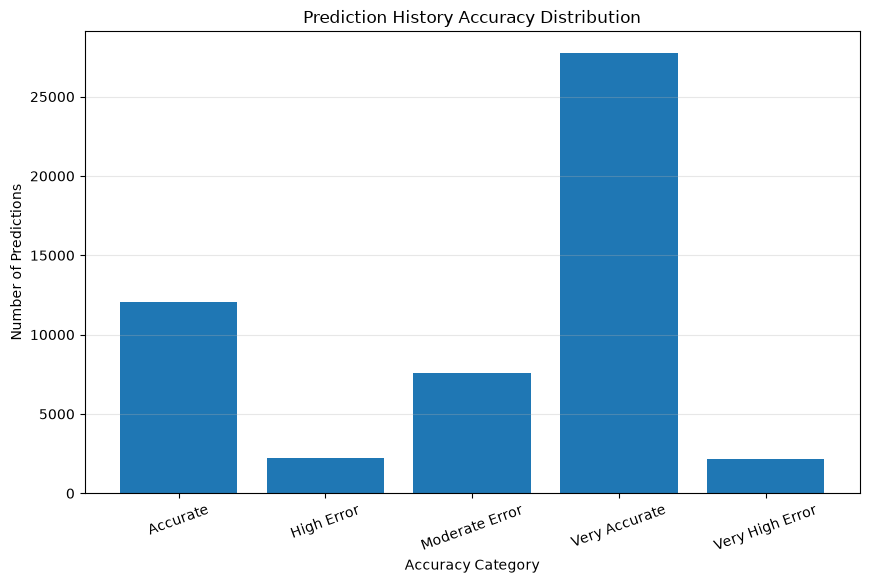

In [22]:
plt.figure(
    figsize=(10, 6)
)

plt.bar(
    accuracy_history[
        "accuracy_category"
    ],
    accuracy_history[
        "prediction_count"
    ]
)

plt.xlabel(
    "Accuracy Category"
)

plt.ylabel(
    "Number of Predictions"
)

plt.title(
    "Prediction History Accuracy Distribution"
)

plt.xticks(
    rotation=20
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [23]:
if "locality" not in prediction_history.columns:
    
    raise ValueError(
        "❌ Locality column is not available."
    )


locality_history = (
    prediction_history
    .groupby("locality")
    .agg(
        prediction_count=(
            "prediction_id",
            "count"
        ),
        
        average_predicted_price=(
            "predicted_price",
            "mean"
        ),
        
        average_actual_price=(
            "actual_price",
            "mean"
        ),
        
        average_error=(
            "absolute_error",
            "mean"
        ),
        
        average_error_percentage=(
            "error_percentage",
            "mean"
        )
    )
    .reset_index()
)

locality_history = (
    locality_history
    .sort_values(
        "prediction_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    locality_history.head(20)
)

,locality,prediction_count,average_predicted_price,average_actual_price,average_error,average_error_percentage
0,Thane,5292,1.576839e+07,1.575273e+07,1.279443e+06,8.157598
1,Mira Road,3162,8.820194e+06,8.756489e+06,5.072112e+05,5.485675
2,Kandivali,2039,1.902520e+07,1.896827e+07,1.651340e+06,7.870504
3,Andheri,2039,3.283146e+07,3.217703e+07,3.208640e+06,10.014119
4,Kharghar,1904,1.393722e+07,1.394416e+07,1.340030e+06,9.830476
5,Dombivali,1872,6.042001e+06,6.019099e+06,3.689874e+05,6.761767
6,Kalyan,1738,6.507935e+06,6.488894e+06,4.941810e+05,8.243563
7,Borivali,1678,2.109490e+07,2.102899e+07,1.431306e+06,7.097082
8,Chembur,1591,2.385927e+07,2.372807e+07,1.918937e+06,8.420596
9,Malad,1522,1.965250e+07,1.938056e+07,1.440471e+06,7.663080


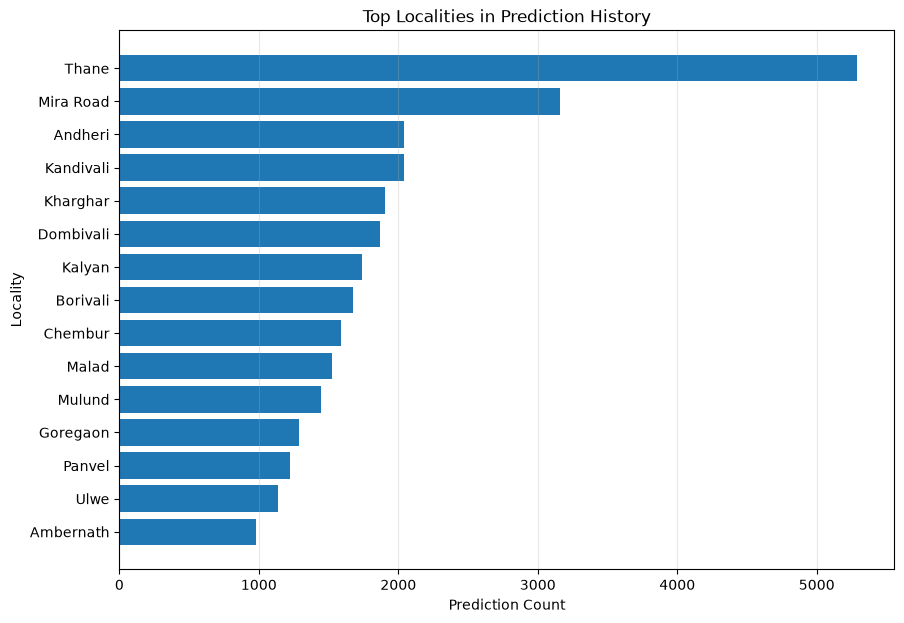

In [24]:
top_localities = (
    locality_history
    .head(15)
    .sort_values(
        "prediction_count",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_localities["locality"],
    top_localities["prediction_count"]
)

plt.xlabel(
    "Prediction Count"
)

plt.ylabel(
    "Locality"
)

plt.title(
    "Top Localities in Prediction History"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

In [25]:
locality_price_history = (
    locality_history
    .sort_values(
        "average_predicted_price",
        ascending=False
    )
    .head(15)
)

display(
    locality_price_history
)

,locality,prediction_count,average_predicted_price,average_actual_price,average_error,average_error_percentage
251,Marine Drive,2,4.991178e+08,5.836834e+08,2.692236e+08,45.690206
152,Churchgate,5,4.917202e+08,5.068904e+08,8.133550e+07,20.937276
310,Napean Sea Road,1,3.258069e+08,3.768722e+08,5.106529e+07,13.549765
84,Malabar Hill,36,2.645042e+08,2.811580e+08,3.063384e+07,10.149267
183,Peddar Road,3,2.602487e+08,1.608333e+08,1.018007e+08,72.354353
289,Oshiwara Police Station Road,1,2.413512e+08,1.600000e+08,8.135121e+07,50.844508
277,Altamount Road,1,2.224366e+08,2.100000e+08,1.243656e+07,5.922172
188,Pali Hill,3,1.661702e+08,1.893356e+08,2.316539e+07,10.693558
118,Juhu Scheme,11,1.504442e+08,1.952273e+08,5.638876e+07,21.459440
85,Marine Lines,33,1.484976e+08,1.437040e+08,1.979835e+07,24.464530


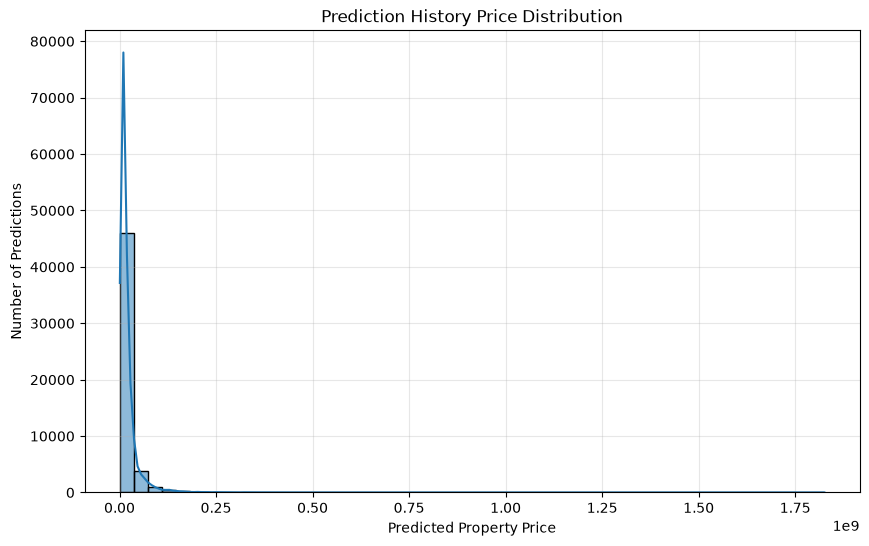

In [26]:
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    prediction_history[
        "predicted_price"
    ],
    bins=50,
    kde=True
)

plt.xlabel(
    "Predicted Property Price"
)

plt.ylabel(
    "Number of Predictions"
)

plt.title(
    "Prediction History Price Distribution"
)

plt.grid(
    alpha=0.3
)

plt.show()

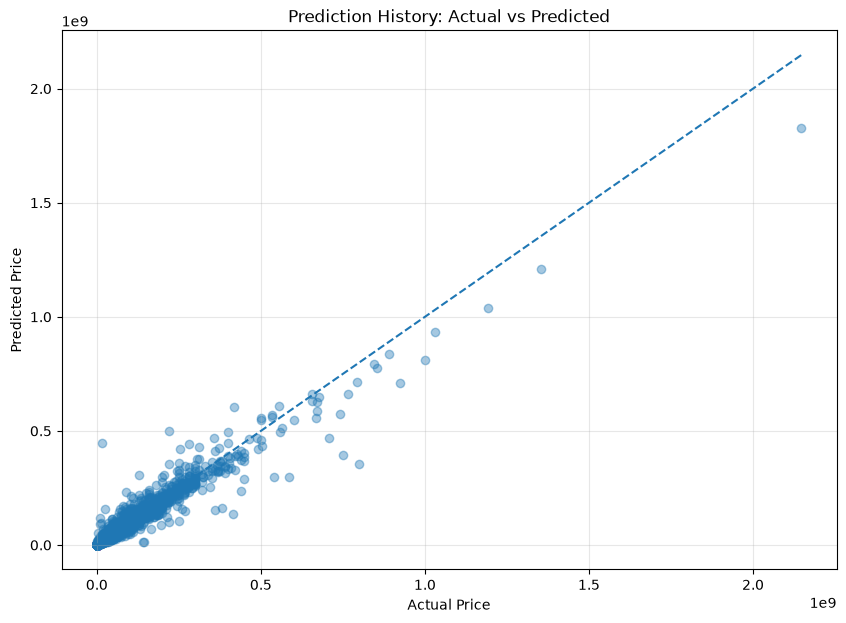

In [27]:
plt.figure(
    figsize=(10, 7)
)

plt.scatter(
    prediction_history[
        "actual_price"
    ],
    prediction_history[
        "predicted_price"
    ],
    alpha=0.4
)

min_value = min(
    prediction_history[
        "actual_price"
    ].min(),
    
    prediction_history[
        "predicted_price"
    ].min()
)

max_value = max(
    prediction_history[
        "actual_price"
    ].max(),
    
    prediction_history[
        "predicted_price"
    ].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Prediction History: Actual vs Predicted"
)

plt.grid(
    alpha=0.3
)

plt.show()

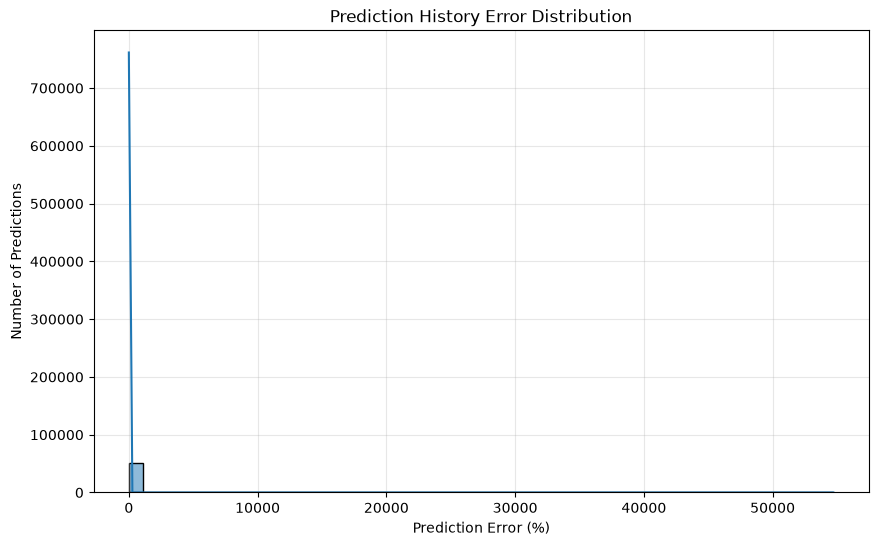

In [28]:
plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    prediction_history[
        "error_percentage"
    ].dropna(),
    bins=50,
    kde=True
)

plt.xlabel(
    "Prediction Error (%)"
)

plt.ylabel(
    "Number of Predictions"
)

plt.title(
    "Prediction History Error Distribution"
)

plt.grid(
    alpha=0.3
)

plt.show()

In [30]:
recent_predictions = (
    prediction_history
    .sort_values(
        "prediction_date",
        ascending=False
    )
    .head(20)
)

print(
    "Recent prediction records:"
)

display(
    recent_predictions
)

Recent prediction records:


,prediction_id,prediction_date,locality,city,property_type,area,bedroom_num,bathroom_num,balcony_num,furnished,age,actual_price,predicted_price,prediction_error,absolute_error,error_percentage,prediction_difference_percent,accuracy_category
0,1,2026-10-03,Kalyan,Mumbai,Apartment,757,2,2,0,Unfurnished,0,6600283,5.988569e+06,6.117139e+05,6.117139e+05,9.267996,-9.267996,Accurate
50340,50341,2026-10-03,Virar,Mumbai,Apartment,800,2,2,0,Semi-Furnished,0,5800000,6.051639e+06,-2.516388e+05,2.516388e+05,4.338600,4.338600,Very Accurate
19770,19771,2026-10-03,Kalyan,Mumbai,Apartment,450,1,1,0,Unfurnished,0,2500000,3.301516e+06,-8.015156e+05,8.015156e+05,32.060625,32.060625,Very High Error
7290,7291,2026-10-03,Taloja,Mumbai,Apartment,1058,2,2,0,Unfurnished,0,5100000,5.284667e+06,-1.846667e+05,1.846667e+05,3.620915,3.620915,Very Accurate
45780,45781,2026-10-03,Karanjade,Mumbai,Apartment,685,1,2,0,Unfurnished,5,4500000,4.458960e+06,4.104000e+04,4.104000e+04,0.912000,-0.912000,Very Accurate
35490,35491,2026-10-03,Ville Parle,Mumbai,Apartment,1201,3,3,3,Unfurnished,4,25000000,2.496413e+07,3.586667e+04,3.586667e+04,0.143467,-0.143467,Very Accurate
19800,19801,2026-10-03,Kharghar,Mumbai,Apartment,1650,3,3,0,Unfurnished,9,17000000,1.754679e+07,-5.467917e+05,5.467917e+05,3.216422,3.216422,Very Accurate
7260,7261,2026-10-03,Thane,Mumbai,Apartment,924,2,2,0,Unfurnished,10,14000000,1.290818e+07,1.091824e+06,1.091824e+06,7.798743,-7.798743,Accurate
35460,35461,2026-10-03,Mulund,Mumbai,Apartment,982,2,2,2,Unfurnished,0,15000000,1.304177e+07,1.958230e+06,1.958230e+06,13.054868,-13.054868,Moderate Error
7410,7411,2026-10-03,Kurla,Mumbai,Apartment,485,1,1,0,Unfurnished,0,4900000,5.083526e+06,-1.835255e+05,1.835255e+05,3.745419,3.745419,Very Accurate


In [31]:
prediction_history_summary = pd.DataFrame({

    "Metric": [
        "Total Predictions",
        "Average Predicted Price",
        "Average Actual Price",
        "Average Absolute Error",
        "Average Error Percentage",
        "Median Predicted Price",
        "Highest Predicted Price",
        "Lowest Predicted Price"
    ],

    "Value": [

        total_predictions,

        prediction_history[
            "predicted_price"
        ].mean(),

        prediction_history[
            "actual_price"
        ].mean(),

        prediction_history[
            "absolute_error"
        ].mean(),

        prediction_history[
            "error_percentage"
        ].mean(),

        prediction_history[
            "predicted_price"
        ].median(),

        prediction_history[
            "predicted_price"
        ].max(),

        prediction_history[
            "predicted_price"
        ].min()
    ]
})

display(
    prediction_history_summary
)

,Metric,Value
0,Total Predictions,5.176700e+04
1,Average Predicted Price,2.037918e+07
2,Average Actual Price,2.029837e+07
3,Average Absolute Error,1.817314e+06
4,Average Error Percentage,9.387648e+00
5,Median Predicted Price,1.224799e+07
6,Highest Predicted Price,1.825561e+09
7,Lowest Predicted Price,8.359773e+05


In [32]:
prediction_history_path = os.path.join(
    OUTPUT_DIR,
    "prediction_history.csv"
)

prediction_history.to_csv(
    prediction_history_path,
    index=False
)

print(
    "✅ Prediction history exported:"
)

print(
    prediction_history_path
)

✅ Prediction history exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\prediction_history.csv


In [33]:
locality_history_path = os.path.join(
    OUTPUT_DIR,
    "prediction_history_by_locality.csv"
)

locality_history.to_csv(
    locality_history_path,
    index=False
)

print(
    "✅ Locality prediction history exported:"
)

print(
    locality_history_path
)

✅ Locality prediction history exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\prediction_history_by_locality.csv


In [34]:
accuracy_history_path = os.path.join(
    OUTPUT_DIR,
    "prediction_accuracy_history.csv"
)

accuracy_history.to_csv(
    accuracy_history_path,
    index=False
)

print(
    "✅ Accuracy history exported:"
)

print(
    accuracy_history_path
)

✅ Accuracy history exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\prediction_accuracy_history.csv


In [35]:
history_summary_path = os.path.join(
    OUTPUT_DIR,
    "prediction_history_summary.csv"
)

prediction_history_summary.to_csv(
    history_summary_path,
    index=False
)

print(
    "✅ Prediction history summary exported:"
)

print(
    history_summary_path
)

✅ Prediction history summary exported:
C:\Users\Tejas Dalvi\OneDrive\Documents\mumbai-house-price-prediction\outputs\prediction_history_summary.csv


In [36]:
history_output_files = [
    prediction_history_path,
    locality_history_path,
    accuracy_history_path,
    history_summary_path
]

print(
    "Checking output files...\n"
)

for file in history_output_files:

    if os.path.exists(file):

        print(
            "✅",
            os.path.basename(file)
        )

    else:

        print(
            "❌",
            os.path.basename(file)
        )

Checking output files...

✅ prediction_history.csv
✅ prediction_history_by_locality.csv
✅ prediction_accuracy_history.csv
✅ prediction_history_summary.csv


In [37]:
print("=" * 65)
print("              PREDICTION HISTORY REPORT")
print("=" * 65)

print(
    f"\nTotal Prediction Records : {total_predictions:,}"
)

print(
    f"Average Predicted Price  : ₹{average_predicted_price:,.2f}"
)

print(
    f"Average Actual Price     : ₹{average_actual_price:,.2f}"
)

print(
    f"Average Absolute Error   : "
    f"₹{prediction_history['absolute_error'].mean():,.2f}"
)

print(
    f"Average Error Percentage : "
    f"{prediction_history['error_percentage'].mean():.2f}%"
)

print(
    "\n" + "=" * 65
)

print(
    "✅ PREDICTION HISTORY ANALYSIS COMPLETED"
)

print(
    "=" * 65
)

              PREDICTION HISTORY REPORT

Total Prediction Records : 51,767
Average Predicted Price  : ₹20,379,180.02
Average Actual Price     : ₹20,298,373.61
Average Absolute Error   : ₹1,817,314.44
Average Error Percentage : 9.39%

✅ PREDICTION HISTORY ANALYSIS COMPLETED


In [38]:
# Conclusion

The Prediction History module has been successfully created.

The system provides:

- Prediction records
- Prediction IDs
- Prediction dates
- Actual prices
- Predicted prices
- Prediction errors
- Accuracy categories
- Locality-wise prediction history
- Price distribution analysis
- Recent prediction records
- Exportable CSV files

The exported prediction history can be integrated into the Flask dashboard in the next development stage.

SyntaxError: invalid syntax (2371604280.py, line 3)